## 45 Day ML Journey - Day010

### Logistic Regression

In [1]:
# import necessary lib.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import f1_score, accuracy_score

### Generating synthetic dataset ...

In [12]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_repeated=0,
                           n_classes=2,
                           n_clusters_per_class=2,
                           class_sep=2,
                           weights=[0.5, 0.5],
                           random_state=42)

X.shape, y.shape

((100, 2), (100,))

### Visualizing the synthetic dataset ...

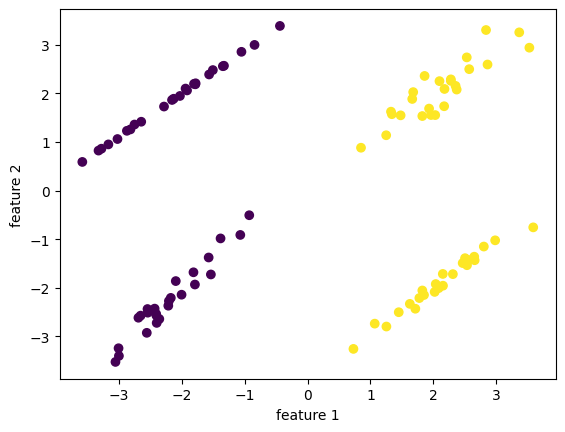

In [14]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

### Splitting dataset for training and testing

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((70, 2), (30, 2), (70,), (30,))

Since, we generated this dataset manually, so we know the weight distribution of both classes are equal therefore, there is no need for handling imbalance classification here.
<br/>
Another thing is Scaling, synthetic dataset generated using make_classification already in range of 0 to 1, although we can perform scaling for mean centric the dataset. Below is the code segment the demonstrates the same.

In [16]:
std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)

### Model training
Now, we try fitting our `LogisticRegression` model for classifying the above dataset.

In [17]:
lr_clf = LogisticRegression(n_jobs=-1)
lr_clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Model testing

In [18]:
X_test = std_scaler.transform(X_test)

y_predictions = lr_clf.predict(X_test)

In [19]:
print("Accuracy : ", accuracy_score(y_test, y_predictions))
print("F1 Score : ", f1_score(y_test, y_predictions))

Accuracy :  1.0
F1 Score :  1.0


As we can clearly see that our model is able to predict all the datapoints correctly.
<br/>
Now we can clearly see that in the below given desision bounday as well.

### Visualizing the decision boundary

<Axes: >

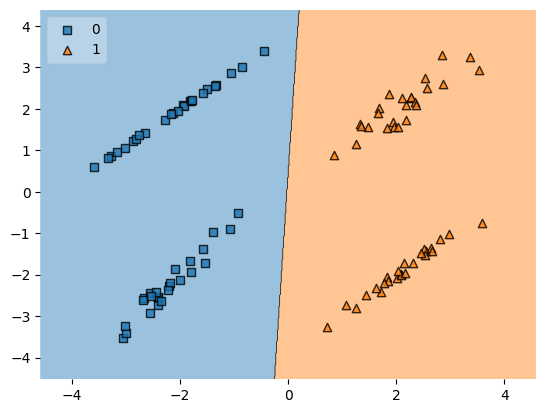

In [21]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y, clf=lr_clf, legend=2)